In [1]:
# Install semua library yang diperlukan
!pip install transformers -q
!pip install openai-whisper -q
!pip install torchaudio -q
!pip install librosa -q
!pip install soundfile -q
!pip install jiwer -q
!pip install datasets -q
!pip install accelerate -q
!pip install ffmpeg-python -q
!apt-get install -y ffmpeg -q

print('✅ Semua library berhasil diinstall!')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 26.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 82.4 MB/s eta 0:00:00
Reading package lists...
Building dependency tree...
Reading state information...
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.
✅ Semua library berhasil diinstall!


In [2]:
import torch
import torchaudio
import librosa
import soundfile as sf
import numpy as np
import whisper
import warnings
import time
import os
import pandas as pd

from transformers import (
    Wav2Vec2ForCTC,
    Wav2Vec2Processor,
    pipeline
)
from jiwer import wer

warnings.filterwarnings('ignore')

# Cek GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'✅ Menggunakan device: {device}')

✅ Menggunakan device: cuda


In [3]:
ENGLISH_AUDIO  = 'English story telling.wav'
INDONESIA_AUDIO = 'Indonesia story telling.wav'
TARGET_SR = 16000  # Semua model ASR membutuhkan 16kHz

def load_audio(filepath, target_sr=TARGET_SR):
    """Load audio dan resample ke target sample rate."""
    audio, sr = librosa.load(filepath, sr=target_sr, mono=True)
    print(f'  📂 File    : {filepath}')
    print(f'  ⏱  Durasi  : {len(audio)/sr:.2f} detik')
    print(f'  🎚  Sample Rate: {sr} Hz')
    return audio, sr

print('=== Loading English Audio ===')
en_audio, en_sr = load_audio(ENGLISH_AUDIO)

print('\n=== Loading Indonesia Audio ===')
id_audio, id_sr = load_audio(INDONESIA_AUDIO)

print('\n✅ Audio berhasil dimuat!')

=== Loading English Audio ===
  📂 File    : English story telling.wav
  ⏱  Durasi  : 95.51 detik
  🎚  Sample Rate: 16000 Hz

=== Loading Indonesia Audio ===
  📂 File    : Indonesia story telling.wav
  ⏱  Durasi  : 89.79 detik
  🎚  Sample Rate: 16000 Hz

✅ Audio berhasil dimuat!


In [4]:
def add_noise(audio, noise_factor=0.02):
    """Tambahkan Gaussian noise ke audio."""
    noise = np.random.normal(0, noise_factor, audio.shape)
    noisy_audio = audio + noise
    # Normalisasi agar tidak clipping
    noisy_audio = noisy_audio / np.max(np.abs(noisy_audio))
    return noisy_audio

def change_speed(audio, sr, speed_factor=1.5):
    """Ubah kecepatan audio menggunakan time stretching."""
    # speed_factor > 1 = lebih cepat, < 1 = lebih lambat
    stretched = librosa.effects.time_stretch(audio, rate=speed_factor)
    return stretched

def save_audio(audio, sr, filepath):
    """Simpan audio ke file WAV."""
    sf.write(filepath, audio, sr)
    print(f'  💾 Disimpan ke: {filepath}')

# ── English Audio Variants ──
print('=== Membuat Variasi Audio Bahasa Inggris ===')
en_noisy = add_noise(en_audio, noise_factor=0.02)
en_fast  = change_speed(en_audio, en_sr, speed_factor=1.5)   # 1.5x lebih cepat
en_slow  = change_speed(en_audio, en_sr, speed_factor=0.75)  # 0.75x lebih lambat

save_audio(en_noisy, en_sr, 'en_noisy.wav')
save_audio(en_fast,  en_sr, 'en_fast.wav')
save_audio(en_slow,  en_sr, 'en_slow.wav')

# ── Indonesia Audio Variants ──
print('\n=== Membuat Variasi Audio Bahasa Indonesia ===')
id_noisy = add_noise(id_audio, noise_factor=0.02)
id_fast  = change_speed(id_audio, id_sr, speed_factor=1.5)
id_slow  = change_speed(id_audio, id_sr, speed_factor=0.75)

save_audio(id_noisy, id_sr, 'id_noisy.wav')
save_audio(id_fast,  id_sr, 'id_fast.wav')
save_audio(id_slow,  id_sr, 'id_slow.wav')

print('\n✅ Semua variasi audio berhasil dibuat!')

=== Membuat Variasi Audio Bahasa Inggris ===
  💾 Disimpan ke: en_noisy.wav
  💾 Disimpan ke: en_fast.wav
  💾 Disimpan ke: en_slow.wav

=== Membuat Variasi Audio Bahasa Indonesia ===
  💾 Disimpan ke: id_noisy.wav
  💾 Disimpan ke: id_fast.wav
  💾 Disimpan ke: id_slow.wav

✅ Semua variasi audio berhasil dibuat!


# MODEL 1: Whisper (mendukung multilingual termasuk Indonesia)

In [5]:
print('📥 Loading Model 1: Whisper (medium)...')
whisper_model = whisper.load_model('medium')  # pilihan: tiny, base, small, medium, large
print('✅ Whisper berhasil dimuat!')

📥 Loading Model 1: Whisper (medium)...


100%|█████████████████████████████████████| 1.42G/1.42G [00:18<00:00, 80.6MiB/s]


✅ Whisper berhasil dimuat!


# MODEL 2: Wav2Vec2 – English (facebook/wav2vec2-large-960h)

In [6]:
print('📥 Loading Model 2: Wav2Vec2 English...')
wav2vec_en_processor = Wav2Vec2Processor.from_pretrained('facebook/wav2vec2-large-960h')
wav2vec_en_model     = Wav2Vec2ForCTC.from_pretrained('facebook/wav2vec2-large-960h').to(device)
wav2vec_en_model.eval()
print('✅ Wav2Vec2 English berhasil dimuat!')

📥 Loading Model 2: Wav2Vec2 English...


preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/843 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/404 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-large-960h
Key                        | Status  | 
---------------------------+---------+-
wav2vec2.masked_spec_embed | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Wav2Vec2 English berhasil dimuat!



# MODEL 3: Wav2Vec2 – Indonesian (XLSR finetuned Indonesian)

In [7]:
print('📥 Loading Model 3: Wav2Vec2 Indonesian...')
wav2vec_id_processor = Wav2Vec2Processor.from_pretrained('cahya/wav2vec2-large-xlsr-indonesian')
wav2vec_id_model     = Wav2Vec2ForCTC.from_pretrained('cahya/wav2vec2-large-xlsr-indonesian').to(device)
wav2vec_id_model.eval()
print('✅ Wav2Vec2 Indonesian berhasil dimuat!')

📥 Loading Model 3: Wav2Vec2 Indonesian...


preprocessor_config.json:   0%|          | 0.00/158 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/250 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/424 [00:00<?, ?it/s]

✅ Wav2Vec2 Indonesian berhasil dimuat!


In [8]:
# ── Fungsi: Transkripsi dengan Whisper ──
def transcribe_whisper(audio_array, sr=TARGET_SR, language=None):
    """
    Transkripsi audio dengan Whisper.
    language: 'en' untuk English, 'id' untuk Indonesia, None = auto-detect
    """
    start = time.time()
    # Whisper membutuhkan float32
    audio_float = audio_array.astype(np.float32)
    result = whisper_model.transcribe(
        audio_float,
        language=language,
        fp16=torch.cuda.is_available()
    )
    elapsed = time.time() - start
    return result['text'].strip(), elapsed


# ── Fungsi: Transkripsi dengan Wav2Vec2 ──
def transcribe_wav2vec2(audio_array, processor, model, sr=TARGET_SR):
    """
    Transkripsi audio dengan Wav2Vec2.
    """
    start = time.time()
    # Tokenisasi input
    inputs = processor(
        audio_array,
        sampling_rate=sr,
        return_tensors='pt',
        padding=True
    )
    input_values = inputs.input_values.to(device)

    # Inferensi
    with torch.no_grad():
        logits = model(input_values).logits

    # Decode
    predicted_ids = torch.argmax(logits, dim=-1)
    transcription  = processor.batch_decode(predicted_ids)[0]
    elapsed = time.time() - start
    return transcription.strip(), elapsed


print('✅ Fungsi transkripsi siap digunakan!')

✅ Fungsi transkripsi siap digunakan!


In [9]:
results = []  # simpan semua hasil untuk analisis

def run_all_models(audio, lang_code, lang_label, condition):
    """Jalankan ketiga model pada satu audio dan simpan hasilnya."""
    print(f'\n{'='*60}')
    print(f'🔬 Kondisi: {condition} | Bahasa: {lang_label}')
    print(f'{'='*60}')

    # ── Whisper ──
    print('\n[Model 1] Whisper')
    txt_w, time_w = transcribe_whisper(audio, language=lang_code)
    print(f'  Hasil : {txt_w[:200]}...' if len(txt_w) > 200 else f'  Hasil : {txt_w}')
    print(f'  Waktu : {time_w:.2f} detik')

    # ── Wav2Vec2 English ──
    print('\n[Model 2] Wav2Vec2 English')
    txt_w2v_en, time_w2v_en = transcribe_wav2vec2(audio, wav2vec_en_processor, wav2vec_en_model)
    print(f'  Hasil : {txt_w2v_en[:200]}...' if len(txt_w2v_en) > 200 else f'  Hasil : {txt_w2v_en}')
    print(f'  Waktu : {time_w2v_en:.2f} detik')

    # ── Wav2Vec2 Indonesian ──
    print('\n[Model 3] Wav2Vec2 Indonesian')
    txt_w2v_id, time_w2v_id = transcribe_wav2vec2(audio, wav2vec_id_processor, wav2vec_id_model)
    print(f'  Hasil : {txt_w2v_id[:200]}...' if len(txt_w2v_id) > 200 else f'  Hasil : {txt_w2v_id}')
    print(f'  Waktu : {time_w2v_id:.2f} detik')

    # Simpan ke results
    results.append({
        'Bahasa': lang_label,
        'Kondisi': condition,
        'Model': 'Whisper',
        'Transkripsi': txt_w,
        'Waktu (s)': round(time_w, 2)
    })
    results.append({
        'Bahasa': lang_label,
        'Kondisi': condition,
        'Model': 'Wav2Vec2-EN',
        'Transkripsi': txt_w2v_en,
        'Waktu (s)': round(time_w2v_en, 2)
    })
    results.append({
        'Bahasa': lang_label,
        'Kondisi': condition,
        'Model': 'Wav2Vec2-ID',
        'Transkripsi': txt_w2v_id,
        'Waktu (s)': round(time_w2v_id, 2)
    })

# ──────────────────────────────────────────────
# EKSPERIMEN 1: Audio Original
# ──────────────────────────────────────────────
print('\n' + '█'*60)
print('EKSPERIMEN 1: AUDIO ORIGINAL')
print('█'*60)

run_all_models(en_audio, lang_code='en', lang_label='English',   condition='Original')
run_all_models(id_audio, lang_code='id', lang_label='Indonesia', condition='Original')


████████████████████████████████████████████████████████████
EKSPERIMEN 1: AUDIO ORIGINAL
████████████████████████████████████████████████████████████

🔬 Kondisi: Original | Bahasa: English

[Model 1] Whisper
  Hasil : One day, I was walking home in the evening. The sky was getting dark and the street was very quiet. I felt a little tired so I walked slowly and looked around. Then I saw a small shop that I had never...
  Waktu : 14.89 detik

[Model 2] Wav2Vec2 English
  Hasil : ONE DAY I WAS WALKING HOME IN THE EVENING THE SKY WAS GETTING DARK AND THE STREET WAS A FERY QUIET I FELT A LITTLE TIRED SO I WALKED SLOWLY AND LOOKED AROUN THEN I SAW A SMALL SHOP THAT I HAD NEVER NO...
  Waktu : 1.86 detik

[Model 3] Wav2Vec2 Indonesian
  Hasil : wandei awas walkinghom indwini diskaiwas getingdgor andostriwos evarikuait aivol ali totair soaiwal selali an lokroraundan aitosemausyop deaihat newernotis bifo idwas ebukto dolai insai wosrang enitlu...
  Waktu : 2.00 detik

🔬 Kondisi: Original | Ba

In [10]:
print('\n' + '█'*60)
print('EKSPERIMEN 2: AUDIO DENGAN NOISE (noise_factor=0.02)')
print('█'*60)

run_all_models(en_noisy, lang_code='en', lang_label='English',   condition='Noisy')
run_all_models(id_noisy, lang_code='id', lang_label='Indonesia', condition='Noisy')


████████████████████████████████████████████████████████████
EKSPERIMEN 2: AUDIO DENGAN NOISE (noise_factor=0.02)
████████████████████████████████████████████████████████████

🔬 Kondisi: Noisy | Bahasa: English

[Model 1] Whisper
  Hasil : One day, I was walking home in the evening. The sky was getting dark and the street was very quiet. I felt a little tired so I walked slowly and looked around. Then I saw a small shop that I had never...
  Waktu : 12.16 detik

[Model 2] Wav2Vec2 English
  Hasil : WONE DAY I WAS WAOOKING HO IN H EVEN THIS STI WAS TITKING BOR AND THIS PIT WASA PERI QUIET I THOUGHT ALITHAFIRE HOGT I WAT TOWLI AND WAT ALONG THEN I SAW AS MOS SHO T I AND NEVER MOTI TEFR IT WAST AND...
  Waktu : 1.86 detik

[Model 3] Wav2Vec2 Indonesian
  Hasil : wondei awaswo tinkodind igindistaiwas etinggar andesti wos ekeirpuaiaioealitoail keaiwok lali eloang dan aisto osemausok teaiaeneh mematis di po diws obucto belai inte wosung entikulut pispu aitoku ke...
  Waktu : 2.09 detik

🔬 K

In [11]:
print('\n' + '█'*60)
print('EKSPERIMEN 3a: AUDIO DIPERCEPAT 1.5x')
print('█'*60)

run_all_models(en_fast, lang_code='en', lang_label='English',   condition='Speed 1.5x')
run_all_models(id_fast, lang_code='id', lang_label='Indonesia', condition='Speed 1.5x')

print('\n' + '█'*60)
print('EKSPERIMEN 3b: AUDIO DIPERLAMBAT 0.75x')
print('█'*60)

run_all_models(en_slow, lang_code='en', lang_label='English',   condition='Speed 0.75x')
run_all_models(id_slow, lang_code='id', lang_label='Indonesia', condition='Speed 0.75x')


████████████████████████████████████████████████████████████
EKSPERIMEN 3a: AUDIO DIPERCEPAT 1.5x
████████████████████████████████████████████████████████████

🔬 Kondisi: Speed 1.5x | Bahasa: English

[Model 1] Whisper
  Hasil : One day, I was walking home in the evening. The sky was really dark and the street was a fair bit quiet. I felt a little tired, so I walked slowly and looked around. Then I saw a small shop that I had...
  Waktu : 9.28 detik

[Model 2] Wav2Vec2 English
  Hasil : ONE DAY I WAS WALKING HOM IN THE EVENING THIS A WAS REALLY WON AN HIS MEY WAS A FAIR WHIT I THOUGHT A LITTLE ARO SO I WALKED SOWLY A LONRORN THEN I SAW AS MOSHOP AN I HAD NEVER NOTID BEFORE HE WAS A B...
  Waktu : 1.04 detik

[Model 3] Wav2Vec2 Indonesian
  Hasil : wanei ayos ogi hoin hiri besayus legar ayus lew pakewai ako kali tear suawat soli halo orang dan laislas mosuk ialihanyag men natisbwa ewsa bosor berimah di sabos rong  uk beswun aikau gris selai sidu...
  Waktu : 1.19 detik

🔬 Kondisi: Spee

In [12]:
# ── Tampilkan tabel hasil ──
df = pd.DataFrame(results)
print('\n===== RINGKASAN HASIL TRANSKRIPSI =====')
display(df[['Bahasa', 'Kondisi', 'Model', 'Waktu (s)', 'Transkripsi']])


===== RINGKASAN HASIL TRANSKRIPSI =====


,Bahasa,Kondisi,Model,Waktu (s),Transkripsi
0,English,Original,Whisper,14.89,"One day, I was walking home in the evening. Th..."
1,English,Original,Wav2Vec2-EN,1.86,ONE DAY I WAS WALKING HOME IN THE EVENING THE ...
2,English,Original,Wav2Vec2-ID,2.00,wandei awas walkinghom indwini diskaiwas getin...
3,Indonesia,Original,Whisper,14.34,"Suatu hari, saya berjalan pulang di malam hari..."
4,Indonesia,Original,Wav2Vec2-EN,1.67,SOTOHARI SAA BRIGLLAM BPULAM DI MALAMHARI LANG...
5,Indonesia,Original,Wav2Vec2-ID,1.91,suatu hari saya berjalan pulang di malam hari ...
6,English,Noisy,Whisper,12.16,"One day, I was walking home in the evening. Th..."
7,English,Noisy,Wav2Vec2-EN,1.86,WONE DAY I WAS WAOOKING HO IN H EVEN THIS STI ...
8,English,Noisy,Wav2Vec2-ID,2.09,wondei awaswo tinkodind igindistaiwas etinggar...
9,Indonesia,Noisy,Whisper,17.54,"Suatu hari, saya berjalan pulang di malam hari..."


In [13]:
# ── Tabel Waktu Inferensi per Model ──
pivot_time = df.pivot_table(
    index=['Bahasa', 'Kondisi'],
    columns='Model',
    values='Waktu (s)'
)
print('\n===== WAKTU INFERENSI (detik) =====')
display(pivot_time)


===== WAKTU INFERENSI (detik) =====


Model                  Wav2Vec2-EN  Wav2Vec2-ID  Whisper
Bahasa    Kondisi                                       
English   Noisy               1.86         2.09    12.16
          Original            1.86         2.00    14.89
          Speed 0.75x         3.08         3.45    10.09
          Speed 1.5x          1.04         1.19     9.28
Indonesia Noisy               1.78         2.02    17.54
          Original            1.67         1.91    14.34
          Speed 0.75x         2.88         3.16    13.63
          Speed 1.5x          1.06         1.22    13.37

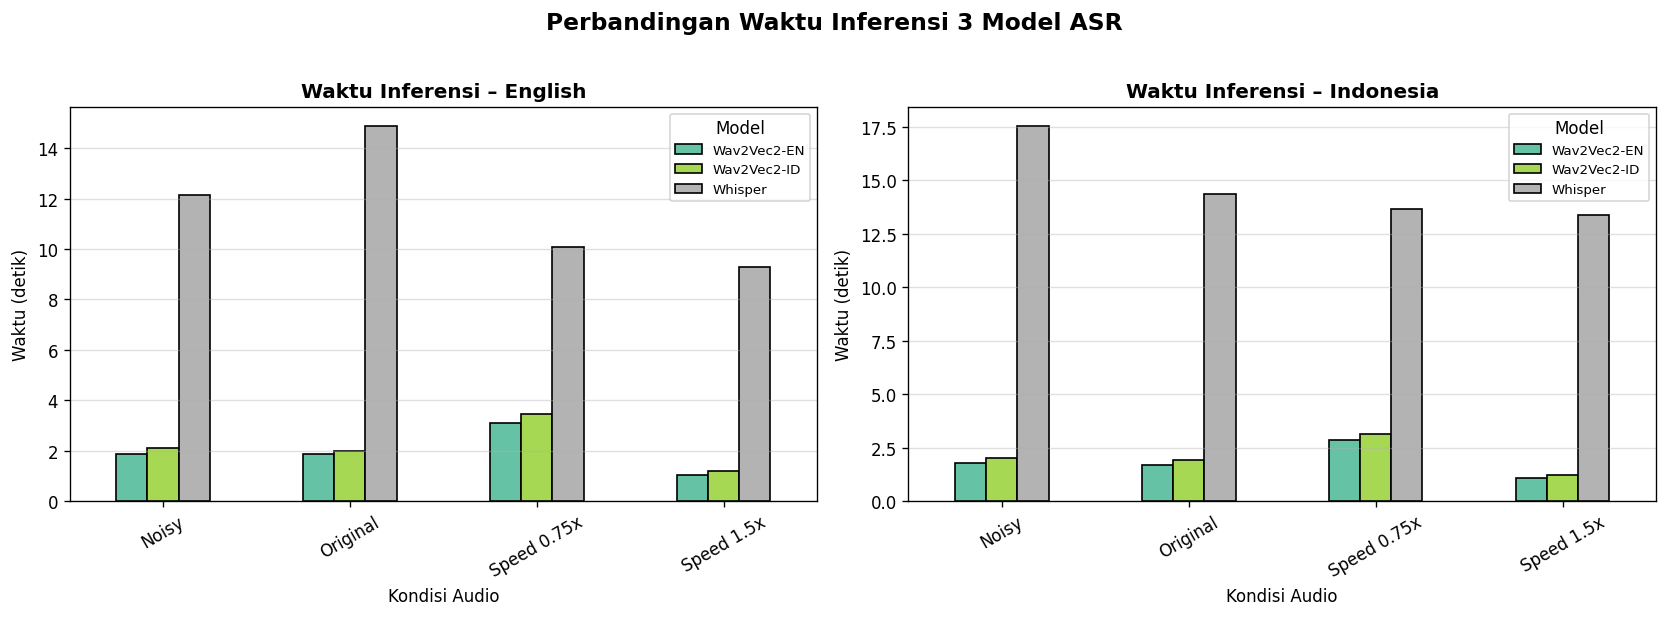


✅ Grafik disimpan sebagai waktu_inferensi.png


In [14]:
# ── Visualisasi Waktu Inferensi ──
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, lang in enumerate(['English', 'Indonesia']):
    df_lang = df[df['Bahasa'] == lang]
    pivot = df_lang.pivot_table(index='Kondisi', columns='Model', values='Waktu (s)')
    pivot.plot(kind='bar', ax=axes[idx], colormap='Set2', edgecolor='black')
    axes[idx].set_title(f'Waktu Inferensi – {lang}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Kondisi Audio')
    axes[idx].set_ylabel('Waktu (detik)')
    axes[idx].tick_params(axis='x', rotation=30)
    axes[idx].legend(title='Model', fontsize=8)
    axes[idx].grid(axis='y', alpha=0.4)

plt.suptitle('Perbandingan Waktu Inferensi 3 Model ASR', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('waktu_inferensi.png', bbox_inches='tight')
plt.show()
print('\n✅ Grafik disimpan sebagai waktu_inferensi.png')

# ── Hitung Word Error Rate (WER) ──

In [15]:
# INSTRUKSI: Isi reference_text dengan teks asli yang kamu rekam
# Ini digunakan sebagai ground truth untuk menghitung akurasi

reference_en = """One day, I was walking home in the evening. The sky was getting dark, and the street was very quiet. I felt a little tired, so I walked slowly and looked around.

Then, I saw a small shop that I had never noticed before. It was a bookstore. The light inside was warm, and it looked peaceful. I felt curious, so I decided to go inside.

When I opened the door, I saw many old books on wooden shelves. There was also an old man behind the table. He smiled at me, but he did not say anything. I smiled back and started looking at the books.

After a few minutes, I found one interesting book. It was simple and had no title. I opened it and began to read. The story was about a person walking home in the evening and entering a bookstore.

I was surprised because it was just like me. I felt a little scared, so I closed the book quickly. When I looked up, the old man was gone.

I left the shop and walked home faster. Until now, I still remember that strange experience."""

reference_id = """Suatu hari, saya berjalan pulang di malam hari. Langit mulai gelap, dan jalanan sangat sepi. Saya merasa sedikit lelah, jadi saya berjalan perlahan dan melihat sekeliling.

Kemudian, saya melihat sebuah toko kecil yang belum pernah saya perhatikan sebelumnya. Itu adalah toko buku. Cahaya di dalamnya hangat, dan tampak damai. Saya merasa penasaran, jadi saya memutuskan untuk masuk.

Ketika saya membuka pintu, saya melihat banyak buku tua di rak kayu. Ada juga seorang pria tua di belakang meja. Dia tersenyum kepada saya, tetapi tidak mengatakan apa pun. Saya membalas senyumannya dan mulai melihat-lihat buku.

Setelah beberapa menit, saya menemukan satu buku yang menarik. Buku itu sederhana dan tanpa judul. Saya membukanya dan mulai membaca. Ceritanya tentang seseorang yang berjalan pulang di malam hari dan memasuki toko buku.

Saya terkejut karena itu persis seperti saya. Saya merasa sedikit takut, jadi saya segera menutup buku itu. Ketika saya mendongak, pria tua itu sudah pergi.

Saya meninggalkan toko dan berjalan pulang lebih cepat. Sampai sekarang, saya masih mengingat pengalaman aneh itu."""

# Hitung WER untuk Kondisi Original saja (sebagai benchmark)
print('===== WORD ERROR RATE (WER) – KONDISI ORIGINAL =====')
print('(0.0 = sempurna, 1.0 = sangat buruk)\n')

wer_rows = []

for _, row in df[df['Kondisi'] == 'Original'].iterrows():
    reference = reference_en if row['Bahasa'] == 'English' else reference_id
    hypothesis = row['Transkripsi'].lower()
    try:
        score = wer(reference.lower(), hypothesis)
    except Exception:
        score = None
    wer_rows.append({
        'Bahasa': row['Bahasa'],
        'Model': row['Model'],
        'WER': round(score, 4) if score is not None else 'N/A'
    })
    print(f"  [{row['Model']:15s}] {row['Bahasa']:10s} → WER = {score:.4f}" if score is not None else f"  [{row['Model']:15s}] {row['Bahasa']:10s} → WER = N/A")

df_wer = pd.DataFrame(wer_rows)
print('\nCatatan: WER rendah = transkripsi lebih akurat')

===== WORD ERROR RATE (WER) – KONDISI ORIGINAL =====
(0.0 = sempurna, 1.0 = sangat buruk)

  [Whisper        ] English    → WER = 0.0368
  [Wav2Vec2-EN    ] English    → WER = 0.3053
  [Wav2Vec2-ID    ] English    → WER = 0.9842
  [Whisper        ] Indonesia  → WER = 0.0539
  [Wav2Vec2-EN    ] Indonesia  → WER = 0.9641
  [Wav2Vec2-ID    ] Indonesia  → WER = 0.4192

Catatan: WER rendah = transkripsi lebih akurat


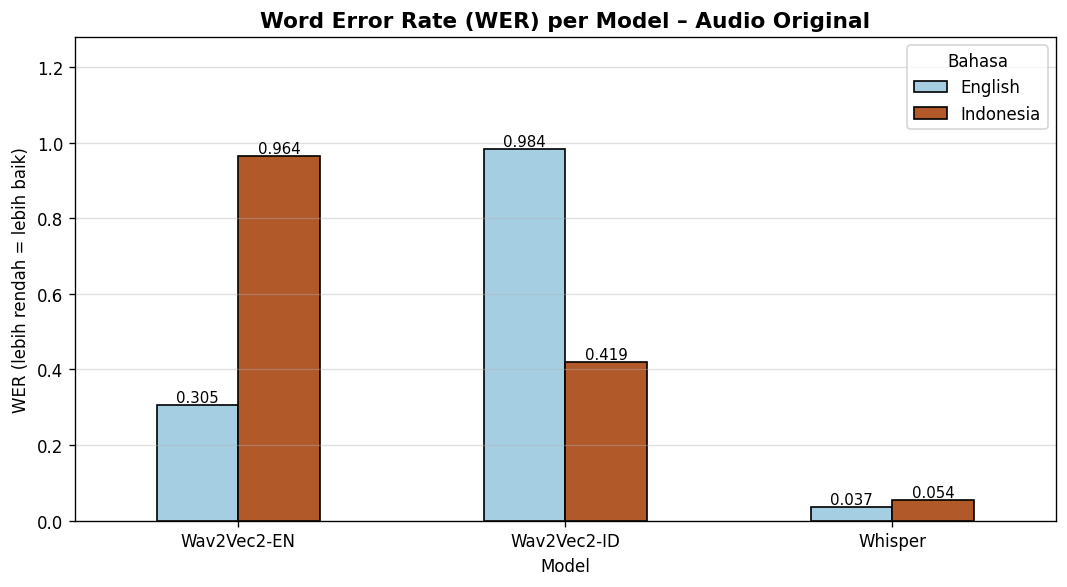


✅ Grafik WER disimpan sebagai wer_comparison.png


In [16]:
# ── Visualisasi WER ──
df_wer_num = df_wer[df_wer['WER'] != 'N/A'].copy()
df_wer_num['WER'] = df_wer_num['WER'].astype(float)

fig, ax = plt.subplots(figsize=(9, 5))
pivot_wer = df_wer_num.pivot(index='Model', columns='Bahasa', values='WER')
pivot_wer.plot(kind='bar', ax=ax, colormap='Paired', edgecolor='black')
ax.set_title('Word Error Rate (WER) per Model – Audio Original', fontsize=13, fontweight='bold')
ax.set_xlabel('Model')
ax.set_ylabel('WER (lebih rendah = lebih baik)')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Bahasa')
ax.grid(axis='y', alpha=0.4)
ax.set_ylim(0, max(df_wer_num['WER'].max() * 1.3, 1.0))

for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('wer_comparison.png', bbox_inches='tight')
plt.show()
print('\n✅ Grafik WER disimpan sebagai wer_comparison.png')